# Bus Route Density vs. Home Sale Price in Fredericksburg
This notebook examines the relationship between single-family home sale prices and proximity to public transit in Fredericksburg, VA. I merged parcel and sales datasets, then filtered out commercial properties, schools, multi-family homes, and other non-residential parcels, leaving only single-family homes. I created a quarter-mile (1,320 ft) spatial buffer around each home and counted how many bus routes intersected that buffer as a measure of "route density." The analysis found a weak positive correlation (r ≈ 0.17) between route density and sale price, driven primarily by the large cluster of homes at low route-density levels where most of the data lives. This suggests that public transit availability has a modest positive association with home prices in Fredericksburg, but is not a dominant driver on its own.

## Setup

In [1]:
# imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load raw parcels (has geometry, no sales info yet)
parcels_geo = gpd.read_file('C:/projects/civic-data/Parcels/Parcels.shp')

# Load sales data
sales = pd.read_excel('C:/projects/civic-data/Parcel_Sales.xls')  # adjust filename if needed

# Merge parcels geometry with sales data
sales_geo = parcels_geo.merge(sales, on='PARID', how='inner')
sales_geo.head()

,GPIN,PARID,Owner,OwnerAddre,OwnerAdd_1,PropertyAd,GICLASS,TaxMap,LivingUnit,NEIGHBORHO,...,SHAPE_STAr,SHAPE_STLe,geometry,OBJECTID,SALEKEY,SaleDate,SalePrice,SaleOwner,SaleInstrument,SaleDeedReference
0,7768-77-4573,7768774573,WILLIAMS THOMAS L & SUSAN C,1208 PICKETT CIR,FREDERICKSBURG VA 22401,1208 PICKETT CIR,Single Family Urban,315 D L15,1,VILLAGE OF IDLEWILD,...,7414.698212,362.389219,"POLYGON ((11767521.154 6787554.756, 11767446.8...",1,2702397,2008-09-16,315000.0,WILLIAMS THOMAS L & SUSAN C,2106 - 2008,0
1,7768-77-4573,7768774573,WILLIAMS THOMAS L & SUSAN C,1208 PICKETT CIR,FREDERICKSBURG VA 22401,1208 PICKETT CIR,Single Family Urban,315 D L15,1,VILLAGE OF IDLEWILD,...,7414.698212,362.389219,"POLYGON ((11767521.154 6787554.756, 11767446.8...",2,2711108,1900-01-01,0.0,RYLAND GROUP INC THE,0,NaN
2,7768-77-4573,7768774573,WILLIAMS THOMAS L & SUSAN C,1208 PICKETT CIR,FREDERICKSBURG VA 22401,1208 PICKETT CIR,Single Family Urban,315 D L15,1,VILLAGE OF IDLEWILD,...,7414.698212,362.389219,"POLYGON ((11767521.154 6787554.756, 11767446.8...",3,2711109,2005-07-29,496990.0,NGUYEN DZIEP N,2604 - 2005,NaN
3,7768-77-4573,7768774573,WILLIAMS THOMAS L & SUSAN C,1208 PICKETT CIR,FREDERICKSBURG VA 22401,1208 PICKETT CIR,Single Family Urban,315 D L15,1,VILLAGE OF IDLEWILD,...,7414.698212,362.389219,"POLYGON ((11767521.154 6787554.756, 11767446.8...",4,2711110,2008-07-31,0.0,FIRST HORIZON HOME LOANS,1770 - 2008,NaN
4,7768-77-4620,7768774620,CLEMONS-HILL RHONDA D & MICHAEL W LEE,1206 PICKETT CIR,FREDERICKSBURG VA 22401,1206 PICKETT CIR,Single Family Urban,315 D L14,1,VILLAGE OF IDLEWILD,...,9809.075225,395.649079,"POLYGON ((11767478.308 6787637.852, 11767476.9...",5,2702396,2005-07-05,502646.0,CLEMONS-HILL RHONDA D & MICHAEL W LEE,2290 - 2005,0


## Clean and Filter\nKeep only the most recent valid sale per parcel, remove non-market transactions and price outliers, and restrict to single-family homes for an apples-to-apples comparison.

In [2]:
# Keep only the most recent valid sale per parcel
sales_geo = sales_geo[sales_geo['SalePrice'] > 0]
sales_geo['SaleDate'] = pd.to_datetime(sales_geo['SaleDate'])
sales_geo = sales_geo.sort_values('SaleDate', ascending=False)
sales_geo = sales_geo.drop_duplicates(subset='PARID', keep='first')

# Remove outlier sale prices
sales_geo = sales_geo[(sales_geo['SalePrice'] >= 10000) & (sales_geo['SalePrice'] <= 2000000)]

# Filter to single-family homes only
sales_geo_sf = sales_geo[sales_geo['GICLASS'] == 'Single Family Urban']
print(len(sales_geo_sf))

# Load bus routes
gdf = gpd.read_file('Bus_Routes/Bus Routes.shp')

# Confirm matching coordinate systems
print(sales_geo_sf.crs)
print(gdf.crs)

6610
EPSG:2283
EPSG:2283


## Spatial Analysis\nBuffer each home by a quarter mile and count intersecting bus routes as a proxy for transit access

In [3]:
sales_geo_sf['buffer'] = sales_geo_sf.geometry.buffer(1320)
buffered = sales_geo_sf.set_geometry('buffer')
joined = gpd.sjoin(buffered, gdf, how='left', predicate='intersects')

route_counts = joined.groupby('PARID').size().reset_index(name='route_density')
sales_geo_sf = sales_geo_sf.merge(route_counts, on='PARID', how='left')
sales_geo_sf['route_density'] = sales_geo_sf['route_density'].fillna(0)

## Results\nTest the correlation between route density and sale price.

0.1683938955734706


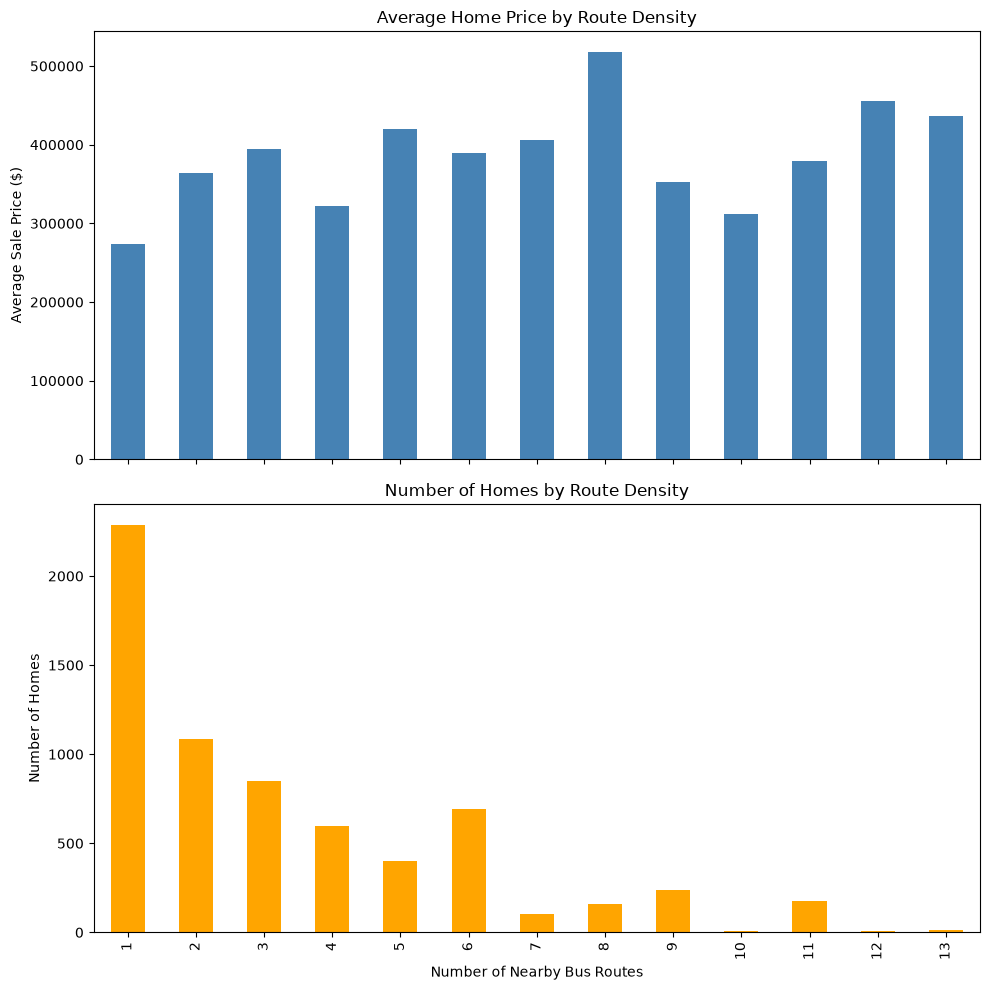

In [4]:
correlation_sf = sales_geo_sf['SalePrice'].corr(sales_geo_sf['route_density'])
print(correlation_sf)

# Final charts
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

avg_price = sales_geo_sf.groupby('route_density')['SalePrice'].mean()
avg_price.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Home Price by Route Density')
axes[0].set_ylabel('Average Sale Price ($)')

home_counts = sales_geo_sf['route_density'].value_counts().sort_index()
home_counts.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Number of Homes by Route Density')
axes[1].set_ylabel('Number of Homes')
axes[1].set_xlabel('Number of Nearby Bus Routes')

plt.tight_layout()
plt.show()